In [136]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

df1 = pd.read_csv("MLEA_111724_otu_table.tsv",sep="\t")
print(df1.shape)
df1.head()

(999, 18)


,ASV_ID,10m_0_mV,10m_200_mV,10m_400_mV,10m_600_mV,10m_800_mV,10m_Cont,20_5m_0_mV,20_5m_200_mV,20_5m_400_mV,20_5m_600_mV,20_5m_800_mV,20_5m_Cont,35m_0_mV,35m_200_mV,35m_400_mV,35m_600_mV,35m_Cont
0,ASV1,66,99,32,64,34,25,72203,127654,159584,92823,72269,115132,202924,23469,147028,7471,135162
1,ASV2,0,0,0,0,0,0,46749,36924,53691,38346,38831,69707,171585,132630,250205,6513,18749
2,ASV3,66511,63841,47285,57228,41759,34774,31061,1619,1101,4657,2334,329,0,0,0,0,1700
3,ASV4,0,0,0,0,0,0,40556,37426,38838,45929,33071,50547,3543,10089,14496,583,4773
4,ASV5,0,0,0,0,0,0,30049,28073,50881,36177,41775,34733,8394,26975,18816,1608,2810


In [137]:
df2 = pd.read_excel("MLEA_111724_otu_table_complete.xlsx", index_col=0)
dtype_mapping = {
    'numeric': float,
    'categorical': str
}
dtypes = dict(zip(df2.columns.tolist(), [dtype_mapping[dtype] for dtype in df2.iloc[0]]))
df2 = pd.read_excel("MLEA_111724_otu_table_complete.xlsx", index_col=0, dtype=dtypes, skiprows=[1])
print(df2.shape)
df2.head()

(13791, 22)


,Taxon,Consensus,Sequence,Extraction_Blank,GL_111724_10m_0_V,GL_111724_10m_200_V,GL_111724_10m_400_V,GL_111724_10m_600_V,GL_111724_10m_800_V,GL_111724_10m_Cnt_V,...,GL_111724_20_5m_400_V,GL_111724_20_5m_600_V,GL_111724_20_5m_800_V,GL_111724_20_5m_Cnt_V,GL_111724_35m_0_V,GL_111724_35m_200_V,GL_111724_35m_400_V,GL_111724_35m_600_V,GL_111724_35m_Cnt_V,GL_111724_AncElec_V
id,,,,,,,,,,,,,,,,,,,,,
00009bf207093f9faba405063b3bd168,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,1,TGGGGAATCTTGGACAATGGGGGCAACCCTGATCCAGCGATGCCGC...,0.0,0.0,0.0,0.0,0.0,0.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00066c1bd7faac09db9ee4418f8c9133,d__Bacteria; p__Planctomycetota; c__Planctomyc...,0.6,TCGAGAATCTTCGGCAATGGGCGAAAGCCTGACCGAGCGACGCCGC...,0.0,81.0,22.0,31.0,26.0,0.0,103.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0006bcf50d74e3d3362657f3e7f98bb3,d__Bacteria; p__Verrucomicrobiota; c__Verrucom...,0.6,TCGAGAATTTTTCTCAATGGGGGAAACCCTGAAGGAGCGACGCCGC...,0.0,0.0,50.0,0.0,0.0,0.0,104.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0009e38c9cbd071a9403ea04c4e169b1,d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...,1,TAAGGAATATTGGACAATGGTCGGAAGACTGATCCAGCCATGCCGC...,0.0,0.0,0.0,0.0,34.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0010c9ded97ac64f27db502a4a174415,d__Bacteria; p__Proteobacteria; c__Alphaproteo...,0.7,TGGGGAATATTGGACAATGGGGGCAACCCTGATCCAGCCATGCCGC...,0.0,0.0,10.0,0.0,0.0,12.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df1.filter(regex="^20_5.*mV",axis=1).sum().head()

20_5m_0_mV      498248
20_5m_200_mV    615259
20_5m_400_mV    823245
20_5m_600_mV    676911
20_5m_800_mV    686759
dtype: int64

In [4]:
df2.filter(regex=".*20_5.*V",axis=1).sum().head()

GL_111724_20_5m_0_V      533778.0
GL_111724_20_5m_200_V    648159.0
GL_111724_20_5m_400_V    864852.0
GL_111724_20_5m_600_V    729734.0
GL_111724_20_5m_800_V    722614.0
dtype: float64

In [5]:
df1 = df1.filter(regex="^20_5m.*mV",axis=1)
df1.head()

,20_5m_0_mV,20_5m_200_mV,20_5m_400_mV,20_5m_600_mV,20_5m_800_mV
0,72203,127654,159584,92823,72269
1,46749,36924,53691,38346,38831
2,31061,1619,1101,4657,2334
3,40556,37426,38838,45929,33071
4,30049,28073,50881,36177,41775


In [6]:
voltages = np.array([0,200,400,600,800])
results = []

for idx, row in df1.iterrows():
    concentrations = row.values
    r_value, p_value = pearsonr(voltages, concentrations)
    results.append([r_value, p_value])

corr_df = pd.DataFrame(results, columns=["r_value","p_value"])
df1 = pd.concat((df1,corr_df),axis=1)
df1.head()

C:\Users\EvanM\AppData\Local\Temp\ipykernel_14000\702555988.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(voltages, concentrations)


,20_5m_0_mV,20_5m_200_mV,20_5m_400_mV,20_5m_600_mV,20_5m_800_mV,r_value,p_value
0,72203,127654,159584,92823,72269,-0.144231,0.816998
1,46749,36924,53691,38346,38831,-0.318922,0.600929
2,31061,1619,1101,4657,2334,-0.668155,0.217691
3,40556,37426,38838,45929,33071,-0.218059,0.724575
4,30049,28073,50881,36177,41775,0.538492,0.349122


<Axes: xlabel='r_value', ylabel='Count'>

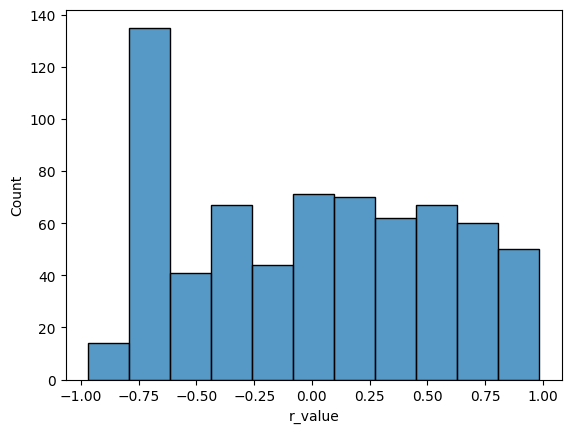

In [7]:
sns.histplot(data=df1,x='r_value')

<Axes: xlabel='r_value', ylabel='p_value'>

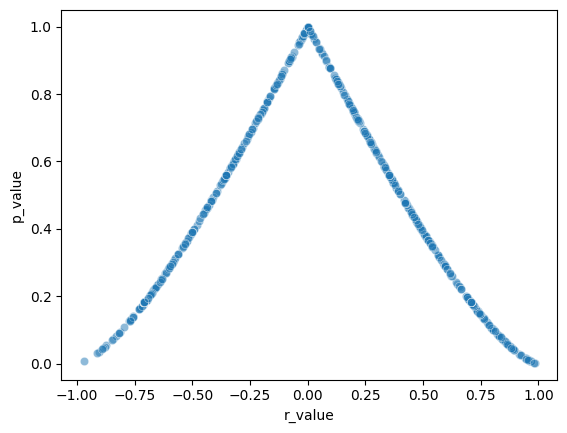

In [8]:
sns.scatterplot(data=df1, x='r_value', y='p_value', alpha=0.5)

In [9]:
print(df1[df1['p_value']<=.01].shape[0])
df1[df1['p_value']<=.01]

10


,20_5m_0_mV,20_5m_200_mV,20_5m_400_mV,20_5m_600_mV,20_5m_800_mV,r_value,p_value
25,3634,5866,6195,7214,9565,0.968270,0.006752
36,1840,4577,8972,10215,11159,0.964145,0.008106
37,0,1027,5943,16827,22012,0.964957,0.007833
40,801,2173,8952,14176,14601,0.965344,0.007704
253,148,399,584,798,860,0.984527,0.002305
371,147,206,445,845,858,0.959634,0.009676
607,99,76,57,2,0,-0.969034,0.006511
674,67,156,206,416,440,0.969497,0.006366
679,118,261,269,378,404,0.959856,0.009597
998,92,138,164,246,317,0.982748,0.002713


In [10]:
print(df1[df1['p_value']<=.05].shape[0])
df1[df1['p_value']<=.05]

32


,20_5m_0_mV,20_5m_200_mV,20_5m_400_mV,20_5m_600_mV,20_5m_800_mV,r_value,p_value
16,129,46,59,0,0,-0.904874,0.034713
25,3634,5866,6195,7214,9565,0.968270,0.006752
28,12565,5287,7164,352,0,-0.912439,0.030691
36,1840,4577,8972,10215,11159,0.964145,0.008106
37,0,1027,5943,16827,22012,0.964957,0.007833
40,801,2173,8952,14176,14601,0.965344,0.007704
47,593,908,1370,1075,1619,0.879923,0.049039
61,2145,1745,3964,3569,4895,0.887989,0.044238
95,510,893,2119,7087,5911,0.894141,0.040682
143,379,779,1556,3560,3311,0.941372,0.016890


In [14]:
def percPositivePearson(alpha,df):
    df_alpha = df[df['p_value']<=alpha]
    pos_r = df_alpha[df_alpha['r_value']>0].shape[0]
    sig_r = df_alpha[df_alpha['r_value']!=0].shape[0]
    return (pos_r/sig_r, sig_r)

results = []
for alpha in np.arange(1.0,0.0,-0.01):
    ppp, pop_size = percPositivePearson(alpha,df1)
    results += [[alpha, ppp, pop_size]]
df1PP = pd.DataFrame(results,columns=["alpha","% Positive Pearson Coef","Population Size"])

<Axes: xlabel='alpha', ylabel='% Positive Pearson Coef'>

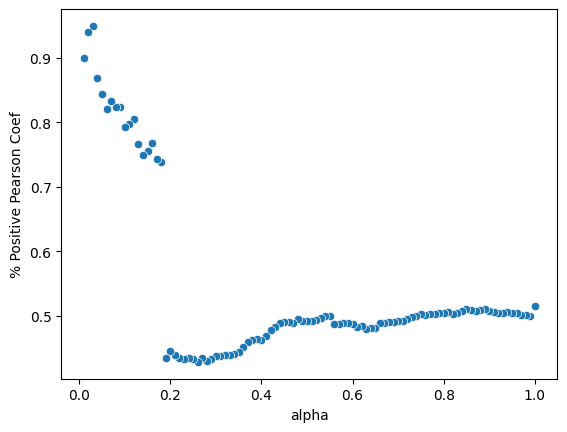

In [15]:
sns.scatterplot(data=df1PP,x='alpha',y="% Positive Pearson Coef")

In [18]:
df2 = df2.filter(regex=".*20_5.*\\d{1,}.*V",axis=1)
voltages = np.array([0,200,400,600,800])
results = []

for idx, row in df2.iterrows():
    concentrations = row.values
    r_value, p_value = pearsonr(voltages, concentrations)
    results.append([r_value, p_value])

corr_df = pd.DataFrame(results, columns=["r_value","p_value"])
df2 = pd.concat((df2,corr_df),axis=1)

results = []
for alpha in np.arange(1.0,0.0,-0.01):
    ppp, pop_size = percPositivePearson(alpha, df2)
    results += [[alpha, ppp, pop_size]]
df2PP = pd.DataFrame(results,columns=["alpha","% Positive Pearson Coef","Population Size"])

C:\Users\EvanM\AppData\Local\Temp\ipykernel_14000\3177136114.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(voltages, concentrations)


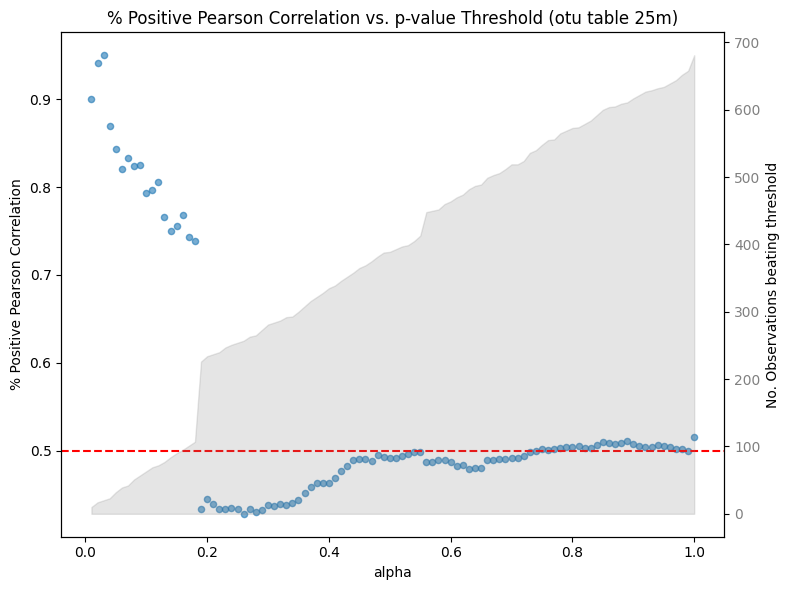

In [22]:
fig, ax1 = plt.subplots(figsize=(8,6))
ax1.scatter(df1PP['alpha'],df1PP['% Positive Pearson Coef'], s=20, alpha=0.6)
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
ax1.set_xlabel("alpha")
ax1.set_ylabel("% Positive Pearson Correlation")

ax2 = ax1.twinx()
ax2.fill_between(df1PP['alpha'],0,df1PP['Population Size'], alpha=0.2, color='gray', label='No. Observations beating threshold')
ax2.set_ylabel('No. Observations beating threshold')
ax2.tick_params(axis='y',labelcolor='gray')

plt.title('% Positive Pearson Correlation vs. p-value Threshold (otu table 25m)')
plt.tight_layout()
plt.show()

In [152]:
count_nonzeros(df1.filter(regex="^20_5.*\\d.*mV"))

Number of Observations with at least 1 non-zero values: 681
Number of Observations with at least 2 non-zero values: 515
Number of Observations with at least 3 non-zero values: 420
Number of Observations with at least 4 non-zero values: 360
Number of Observations with at least 5 non-zero values: 279


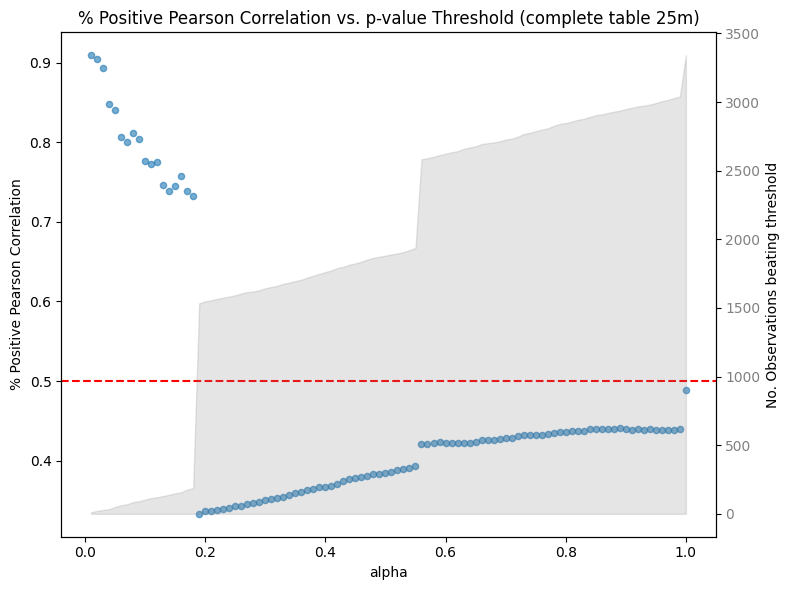

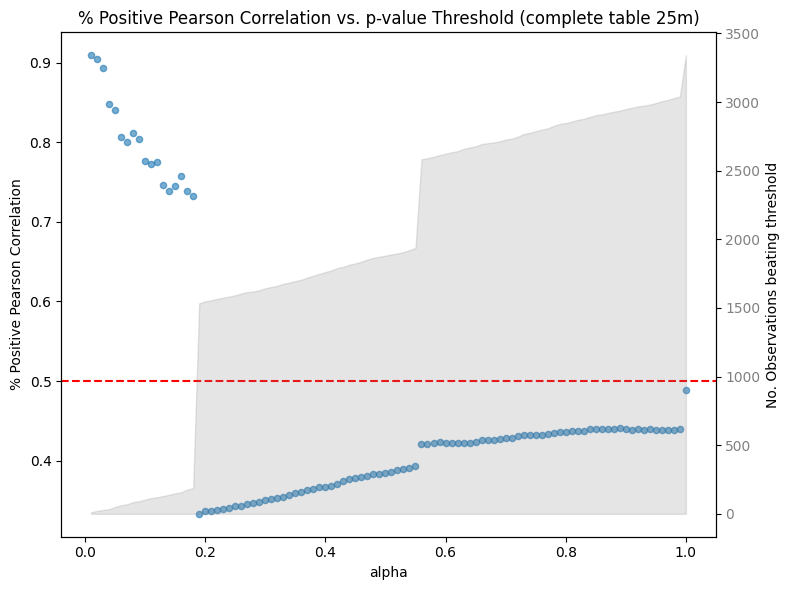

In [27]:
# Run this test again on Df2, dropping all-zero rows (any row where the values for this depth are all 0).
df2 = df2.filter(regex=".*20_5.*\\d{1,}.*V",axis=1)
df2_dropZeros = df2[(df2!=0).any(axis=1)]
voltages = np.array([0,200,400,600,800])
results = []

# Calculating the Pearson Correlation Coefficients for each row.
for idx, row in df2_dropZeros.iterrows():
    concentrations = row.values
    r_value, p_value = pearsonr(voltages, concentrations)
    results.append([r_value, p_value])

corr_df = pd.DataFrame(results, columns=["r_value","p_value"])
df2_dropZeros = pd.concat((df2_dropZeros,corr_df),axis=1)

# Calculating %PPC for each alpha value
results = []
for alpha in np.arange(1.0,0.0,-0.01):
    ppp, pop_size = percPositivePearson(alpha,df2_dropZeros)
    results += [[alpha, ppp, pop_size]]
df2_dz_PP = pd.DataFrame(results,columns=["alpha","% Positive Pearson Coef", "Population Size"])

# Plotting %PPC vs. alpha for DF2 (0s dropped)
fig, ax1 = plt.subplots(figsize=(8,6))
ax1.scatter(df2_dz_PP['alpha'],df2_dz_PP['% Positive Pearson Coef'], s=20, alpha=0.6)
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
ax1.set_xlabel("alpha")
ax1.set_ylabel("% Positive Pearson Correlation")

ax2 = ax1.twinx()
ax2.fill_between(df2_dz_PP['alpha'],0,df2_dz_PP['Population Size'], alpha=0.2, color='gray', label='No. Observations beating threshold')
ax2.set_ylabel('No. Observations beating threshold')
ax2.tick_params(axis='y',labelcolor='gray')

plt.title('% Positive Pearson Correlation vs. p-value Threshold (complete table 25m)')
plt.tight_layout()
plt.show()

In [222]:
# Now let's simulate a dataset with a small sample of populations showing a significant positive correlation within a large population showing no correlation.
def simulated_pop(n_positive=20, n_negative=0, n_total=1000, noise_level=(0.3,0.3,0.3), corr = (1,2) , gen_range = (0,50000), normalize=True):
    simulated_data=[]
    voltages = np.array([0,200,400,600,800])

    # Create sub-population with positive correlation
    for i in range(n_positive):
        slope = np.random.uniform(corr[0], corr[1])
        intercept = np.random.uniform(gen_range[0],gen_range[1])
        concentrations = slope*voltages + intercept
        concentrations += np.random.normal(0, noise_level[0]*concentrations.std(), 5)
        simulated_data.append(concentrations)

    # Create sub-population with negative correlation
    for i in range(n_negative):
        slope = np.random.uniform(-10.0, -0.1)
        intercept = np.random.uniform(0,50000)
        concentrations = slope*voltages + intercept
        concentrations += np.random.normal(0, noise_level[1]*concentrations.std(), 5)
        simulated_data.append(concentrations)
        
    # Create general population with no correlation
    for i in range(n_total-(n_positive+n_negative)):
        center = np.random.uniform(0,50000)
        concentrations = np.random.normal(center, center * noise_level[2], 5)
        simulated_data.append(concentrations)

    simulated_data = np.array(simulated_data)

    # Option to normalize data along columns, effectively turning each column into a % of total pop measurement rather than a raw population size.
    if normalize:
        simulated_data = simulated_data/np.sum(simulated_data, axis=0)

    return pd.DataFrame(np.array(simulated_data),columns=[str(voltage) for voltage in voltages.tolist()])

# Let's test it out.
df_sim = simulated_pop()
df_sim.head()

,0,200,400,600,800
0,0.001848,0.001927,0.001975,0.001938,0.001934
1,0.001493,0.001543,0.001596,0.001568,0.001563
2,0.000823,0.000858,0.000901,0.000893,0.000892
3,0.001731,0.001802,0.001853,0.001820,0.001826
4,0.000108,0.000132,0.000139,0.000151,0.000165


In [146]:
# Let's define functions for the pipeline of calculating %PPC and Graphing so we can more easily mess around with the parameters.
def calc_ppp(df, voltages=np.array([0,200,400,600,800])):
    results=[]
    
    for idx, row in df.iterrows():
        concentrations = row.values
        r_value, p_value = pearsonr(voltages, concentrations)
        results.append([r_value, p_value])
    print(results[0])
    corr_df = pd.DataFrame(results, columns=["r_value","p_value"])
    df = pd.concat((df,corr_df),axis=1)
    
    # Calculating %PPC for each alpha value
    results = []
    for alpha in np.arange(1.0,0.0,-0.01):
        ppp, pop_size = percPositivePearson(alpha,df)
        results += [[alpha, ppp, pop_size]]

    # return %PPC and Pop-size df.
    return pd.DataFrame(results,columns=["alpha","% Positive Pearson Coef", "Population Size"])

# Now define the graphing function to easily create the graph for a ppp dataframe
def graph_ppp(df, name="simulated population", include_pop_size=True):
    # Plotting %PPC vs. alpha for DF2 (0s dropped)
    fig, ax1 = plt.subplots(figsize=(8,6))
    ax1.scatter(df['alpha'],df['% Positive Pearson Coef'], s=20, alpha=0.6)
    ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
    ax1.set_ylim(0,1)
    ax1.set_xlabel("alpha")
    ax1.set_ylabel("% Positive Pearson Correlation")

    if include_pop_size:
        ax2 = ax1.twinx()
        ax2.fill_between(df['alpha'],0,df['Population Size'], alpha=0.2, color='gray', label='No. Observations beating threshold')
        ax2.set_ylabel('No. Observations beating threshold')
        ax2.tick_params(axis='y',labelcolor='gray')
    
    plt.title(f'% Positive Pearson Correlation vs. p-value Threshold ({name})')
    plt.tight_layout()
    plt.show()

[np.float64(0.6812092861658898), np.float64(0.2054228687921189)]


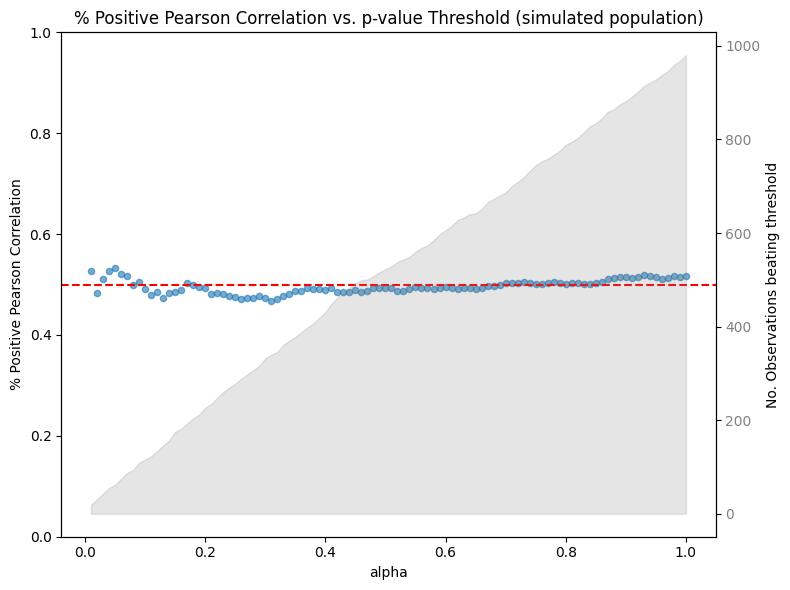

In [147]:
df_sim = simulated_pop()
graph_ppp(calc_ppp(df_sim))

[np.float64(-0.650066736746075), np.float64(0.2350102438607967)]


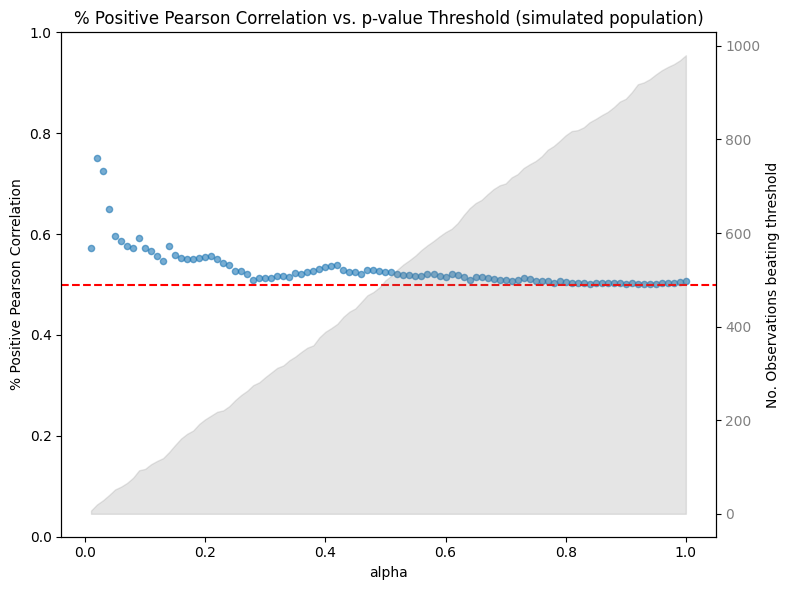

In [71]:
df_sim2 = simulated_pop(n_positive=0)
graph_ppp(calc_ppp(df_sim2))

[np.float64(0.03151238193784578), np.float64(0.959883830684672)]


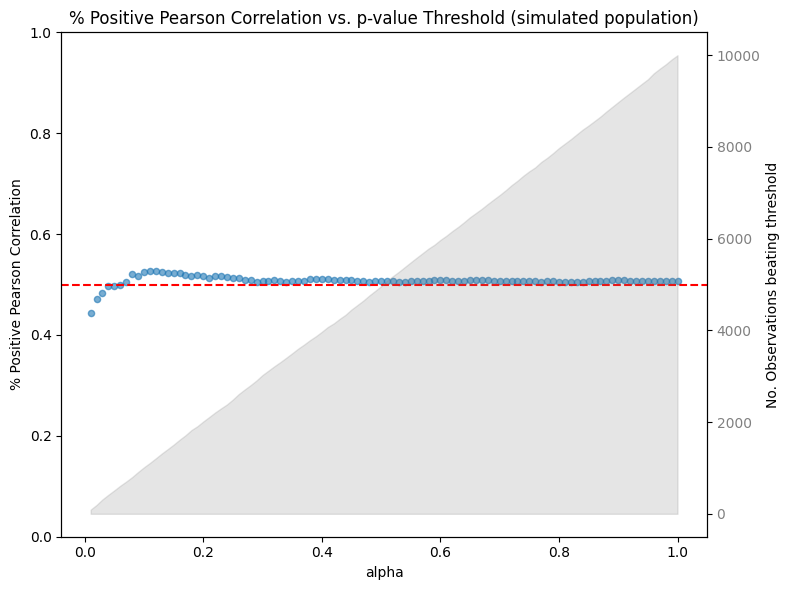

In [65]:
df_sim2 = simulated_pop(n_positive=0,n_negative=0, n_total=10000)
graph_ppp(calc_ppp(df_sim2))

[np.float64(-0.2826041972083473), np.float64(0.6450257912873439)]


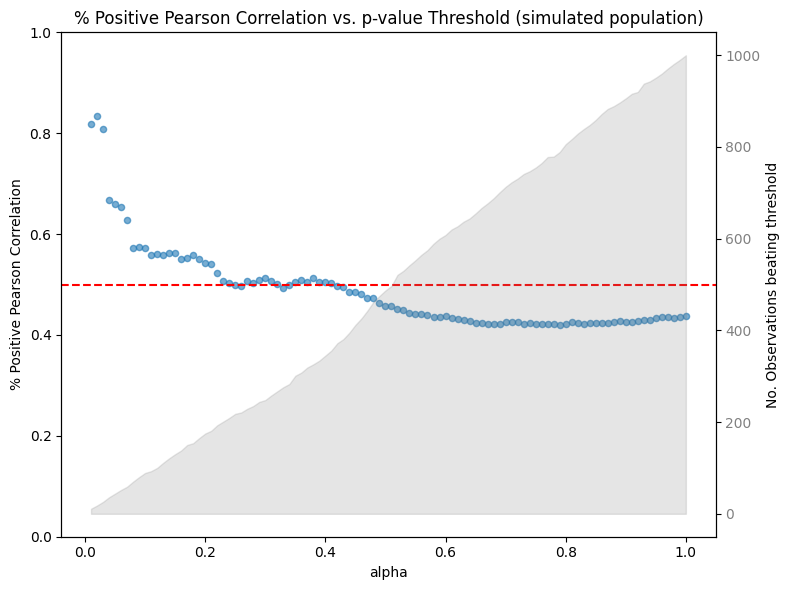

In [133]:
df_sim2 = simulated_pop(n_positive=200, n_negative=0, n_total=1000, noise_level=(0.25,0.6,2.0))
graph_ppp(calc_ppp(df_sim2))

[np.float64(-0.5109843109872624), np.float64(0.37893506536333954)]


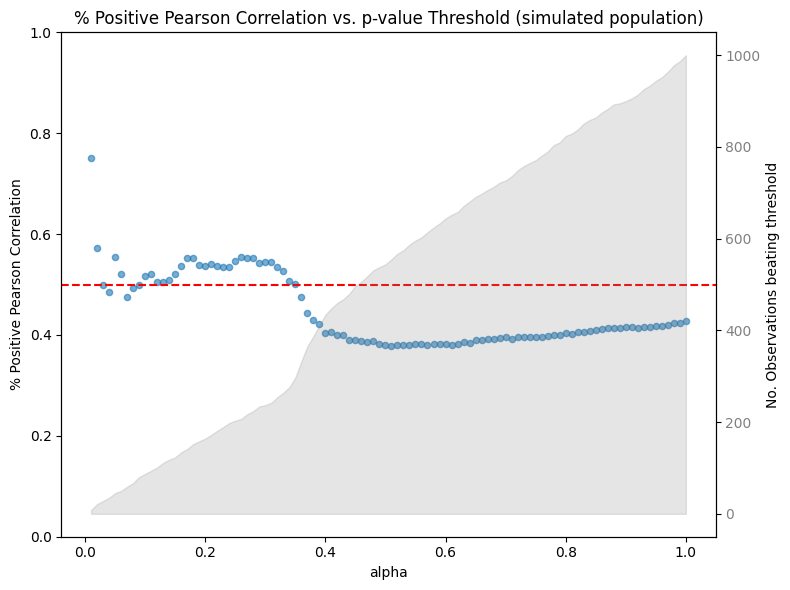

In [134]:
df_sim2 = simulated_pop(n_positive=200, n_negative=0, n_total=1000, noise_level=(0.25,0.6,2.0))
graph_ppp(calc_ppp(df_sim2))

[np.float64(0.9376403691214726), np.float64(0.018517594159165422)]


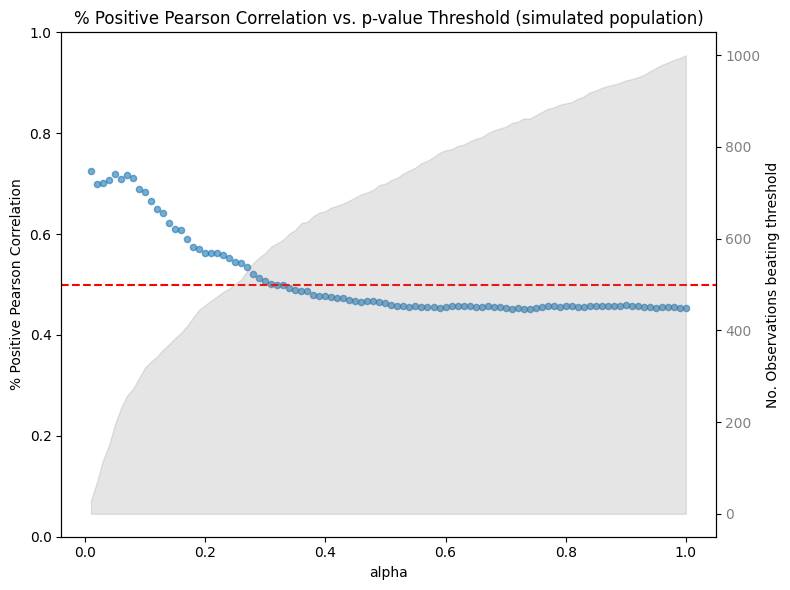

In [266]:
df_sim2 = simulated_pop(n_positive=200, n_negative=0, n_total=1000, corr=(500,500), noise_level=(0.10,0.6,2))
graph_ppp(calc_ppp(df_sim2))

C:\Users\EvanM\AppData\Local\Temp\ipykernel_14000\2792556866.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(voltages, concentrations)


[np.float64(-0.5689279357150498), np.float64(0.3168555318423022)]


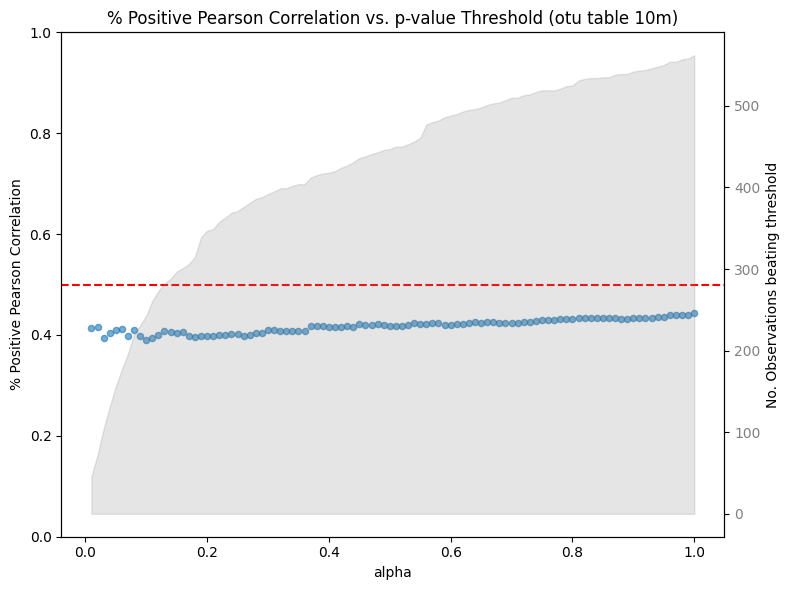

In [200]:
df_10m = df1.filter(regex="^10.*mV",axis=1)
graph_ppp(calc_ppp(df_10m),name="otu table 10m")

In [161]:
# results = []
# for idx, row in df_10m.iterrows():
#     concentrations = row.values
#     r_value, p_value = pearsonr(voltages, concentrations)
#     results.append([r_value, p_value])
# corr_df = pd.DataFrame(results, columns=["r_value","p_value"])
# df_10m = pd.concat((df_10m,corr_df),axis=1)
df_10m.sort_values("p_value").head(10)

,10m_0_mV,10m_200_mV,10m_400_mV,10m_600_mV,10m_800_mV,r_value,p_value
105,1407,1081,865,470,263,-0.995858,0.000320
56,1491,1268,786,480,239,-0.992628,0.000759
899,42,114,189,262,292,0.991090,0.001008
13,25084,21377,13225,5550,1832,-0.990981,0.001027
924,289,200,113,56,9,-0.990379,0.001131
512,150,203,387,539,676,0.989990,0.001200
440,20,103,241,306,483,0.989692,0.001254
109,1566,1267,956,443,328,-0.987522,0.001670
70,3939,3072,2529,1014,624,-0.985190,0.002159
834,261,187,103,39,19,-0.982181,0.002848


C:\Users\EvanM\AppData\Local\Temp\ipykernel_14000\2792556866.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(voltages, concentrations)


[np.float64(-0.6282535331532083), np.float64(0.3717464668467918)]


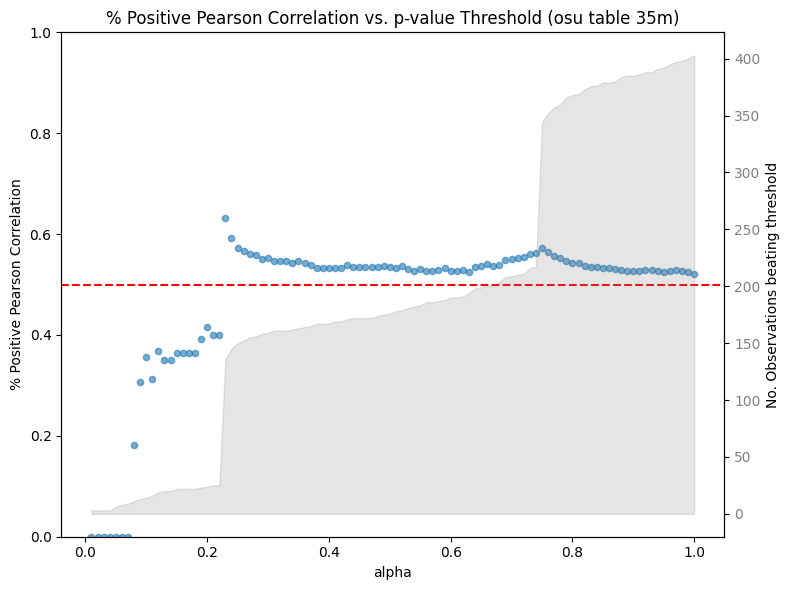

In [149]:
df_35m = df1.filter(regex="^35.*mV",axis=1)
graph_ppp(calc_ppp(df_35m, voltages = np.array([0,200,400,600])),name="osu table 35m")

In [150]:
def count_nonzeros(df):
    for n in range(df.shape[1]):
        nonzero = (df != 0).sum(axis=1)
        filtered = df[nonzero > n]
        print(f"Number of Observations with at least {n+1} non-zero values: {filtered.shape[0]}")
count_nonzeros(df_35m)

Number of Observations with at least 1 non-zero values: 403
Number of Observations with at least 2 non-zero values: 181
Number of Observations with at least 3 non-zero values: 86
Number of Observations with at least 4 non-zero values: 30


Number of Observations with at least 1 non-zero values: 791
Number of Observations with at least 2 non-zero values: 213
Number of Observations with at least 3 non-zero values: 89
Number of Observations with at least 4 non-zero values: 30


C:\Users\EvanM\AppData\Local\Temp\ipykernel_14000\2792556866.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, p_value = pearsonr(voltages, concentrations)


[np.float64(nan), np.float64(nan)]


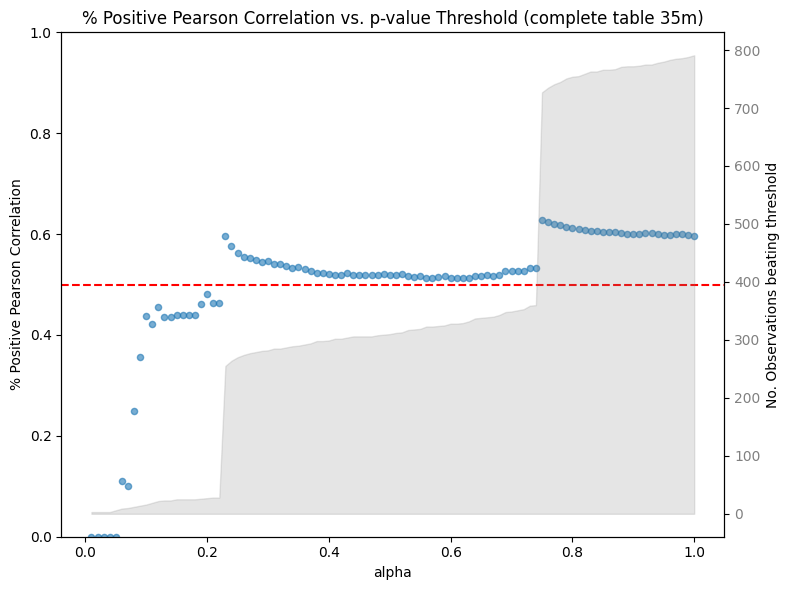

In [154]:
df_35m_complete = df2.filter(regex=".*35.*\\d.*V",axis=1)
df_35m_complete.head()
count_nonzeros(df_35m_complete)
graph_ppp(calc_ppp(df_35m_complete,voltages = np.array([0,200,400,600])),name="complete table 35m")